# Практическое задание с самопроверкой «Проверка гипотез»

1.   Постройте гистограммы плотности распределения объёмов продаж для Франции и Германии и определите типы распределений.
2.   С помощью стат. критериев сравните объёмы продаж во Франции и Германии:
Гипотеза: «Объёмы продаж Франции отличаются от объёмов продаж Германии».
3.   Сделайте выводы по результатам проверки.

**Чек-лист самопроверки:**
*   Построены графики объёмов продаж по отдельным странам.
*   Проведено сравнение объёмов продаж Франции и Германии.
*   Сделаны выводы по результатам проверки.







In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка и просмотр данных

In [ ]:
df = pd.read_excel('data_hw_2__upd_.xlsx')
df.head()

,InvoiceNo,CustomerID,Country,InvoiceDate,Description,TotalPrice
0,537693,12441,France,2010-12-08,WRAP I LOVE LONDON,51.11
1,537693,12441,France,2010-12-08,VINTAGE CARAVAN GIFT WRAP,43.61
2,537693,12441,France,2010-12-08,BLUE SCANDINAVIAN PAISLEY WRAP,73.08
3,537693,12441,France,2010-12-08,PAPER CHAIN KIT VINTAGE CHRISTMAS,39.17
4,537693,12441,France,2010-12-08,PAPER CHAIN KIT 50'S CHRISTMAS,57.48


In [ ]:
df['Country'].unique()

array(['France', 'Germany', 'Norway'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    1200 non-null   object        
 1   CustomerID   1200 non-null   int64         
 2   Country      1200 non-null   object        
 3   InvoiceDate  1200 non-null   datetime64[ns]
 4   Description  1200 non-null   object        
 5   TotalPrice   1200 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 56.4+ KB


In [ ]:
df.describe()

,CustomerID,InvoiceDate,TotalPrice
count,1200.000000,1200,1200.000000
mean,12459.749167,2011-06-08 08:03:36.000000256,50.640212
min,12350.000000,2010-12-01 00:00:00,0.320000
25%,12433.000000,2011-01-07 00:00:00,36.312500
50%,12479.500000,2011-08-12 00:00:00,49.300000
75%,12491.000000,2011-11-01 00:00:00,63.225000
max,12535.000000,2011-12-09 00:00:00,152.700000
std,43.393783,NaN,19.966028


Формирование выборок по странам

In [ ]:
# Формирование выборок
df_fra = df[df['Country'] == 'France']
df_ger = df[df['Country'] == 'Germany']

print('Выборки имеют одинаковую длинну: ', len(df_fra) == len(df_ger))

Выборкки имеют одинаковую длинну:  True


Плотности распределения объёмов продаж

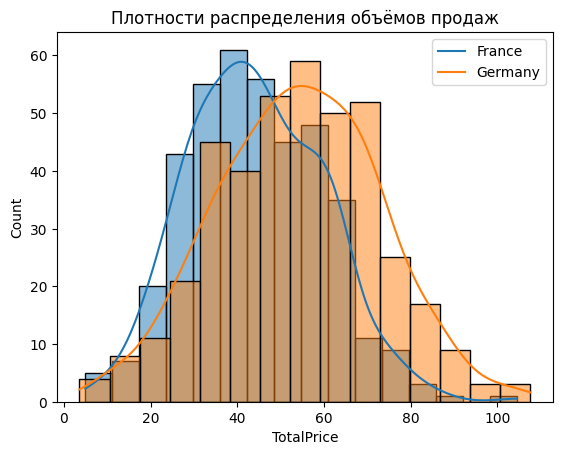

In [ ]:
sns.histplot(df_fra['TotalPrice'], kde=True)
sns.histplot(df_ger['TotalPrice'], kde=True)
plt.title('Плотности распределения объёмов продаж')
plt.legend(['France', 'Germany'])
plt.show()

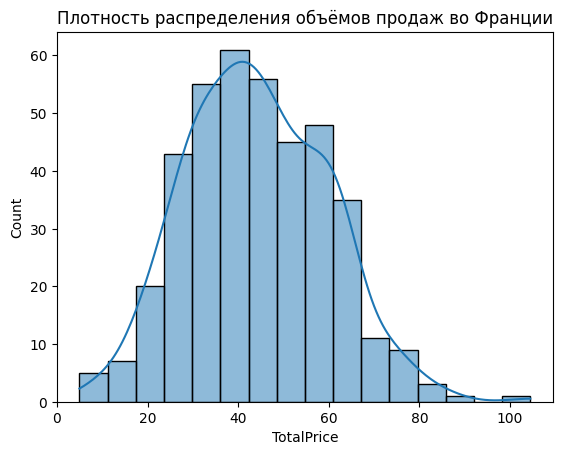

In [ ]:
# по отдельности
sns.histplot(df_fra['TotalPrice'], kde=True)
plt.title('Плотность распределения объёмов продаж во Франции')
plt.show()

Распределение объемов продаж во Франции - чуть положительное (что подтверждается тем, что медиана меньше среднего арифметического), но близко к нормальному

In [ ]:
print(f'Медиана продаж во Франции: {df_fra['TotalPrice'].median()}')
print(f'Среднее значение продаж во Франции: {df_fra['TotalPrice'].mean()}')

Медиана продаж во Франции: 43.43
Среднее значение продаж во Франции: 44.1908375


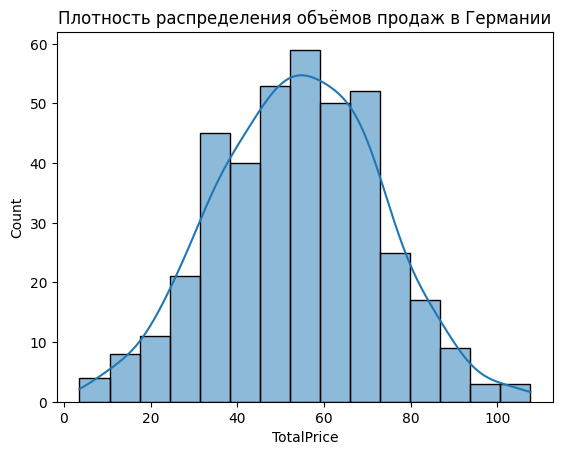

In [ ]:
# по отдельности
sns.histplot(df_ger['TotalPrice'], kde=True)
plt.title('Плотность распределения объёмов продаж в Германии')
plt.show()

Распределение объемов продаж в Германии - чуть отрицательное (что подтверждается тем, что медиана больше среднего арифметического), но близко к нормальному

In [ ]:
print(f'Медиана продаж в Германии: {df_ger['TotalPrice'].median()}')
print(f'Среднее значение продаж в Германии: {df_ger['TotalPrice'].mean()}')

Медиана продаж в Германии: 54.49
Среднее значение продаж в Германии: 53.9649


Подключения библиотек статистических критериев и задание уровня значимости

In [ ]:
from scipy.stats import ttest_ind
# t-критерий Стьюдента. Проверяет гипотезу H0: средние двух выборок равны.
# Применять, если данные распределены нормально.
# Параметр equal_var=False — для случая неравных дисперсий (критерий Уэлча).
from scipy.stats import mannwhitneyu
# U-критерий Манна-Уитни (ранговый). Проверяет гипотезу H0: распределения двух выборок одинаковы (обычно интерпретируется как равенство медиан).
# Непараметрический аналог t-теста. Применять при ненормальном распределении или наличии выбросов.

alpha = 0.05                          # Уровень значимости

Проведение Т-Теста (t-критерий Стьюдента)

Нулевая гипотеза H0: выборки значимо не отличаются, т.е. продажи во Франции и Германии значимо не отличаются

In [ ]:
result = ttest_ind(df_fra['TotalPrice'], df_ger['TotalPrice'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


Вывод: Подтверждаем альтернативную гипотезу. Объёмы продаж во Франции статистически значимо отличаются от объёмов продаж в Германии

Проведение теста Манна — Уитни (U-критерий Манна — Уитни)

In [ ]:
result = mannwhitneyu(df_fra['TotalPrice'], df_ger['TotalPrice'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


Вывод: Подтверждаем альтернативную гипотезу. Объёмы продаж во Франции статистически значимо отличаются от объёмов продаж в Германии